In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path

REPO = Path('..').resolve()
DATASET_DIR = (REPO / 'results' /
    'mle_distributions_shotmax10_a1e8')#R40_N200_A1000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx100um'
    #'_sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000')

def load_runs(prefix):
    runs = []
    for pkl in sorted(DATASET_DIR.glob(f'{prefix}_run_*.pkl')):
        with open(pkl, 'rb') as f:
            runs.append(pickle.load(f))
    return runs

moment_runs = load_runs('map_moment')
prior_runs  = load_runs('map_prior')
oracle_runs  = load_runs('map_true_eta')

print(f'Loaded {len(moment_runs)} map_moment runs, {len(prior_runs)} map_prior runs, {len(oracle_runs)} map_true_eta runs')

As_true = moment_runs[0]['As_true']
Ac_true = moment_runs[0]['Ac_true']
print(f'As_true={As_true:.4f}  Ac_true={Ac_true:.4f}')


Loaded 80 map_moment runs, 80 map_prior runs, 80 map_true_eta runs
As_true=0.0878  Ac_true=0.0479


In [2]:
def collect(runs):
    return np.array([r['beta_hat'] for r in runs])   # (n_runs, 2)

beta_moment = collect(moment_runs)
beta_prior  = collect(prior_runs)
beta_oracle = collect(oracle_runs)

for label, betas in [('MAP-moment', beta_moment), ('MAP-prior', beta_prior), ('MAP-oracle', beta_oracle)]:
    print(f'{label}:  As = {betas[:,0].mean():.4e} ± {betas[:,0].std():.4e}'
          f'   Ac = {betas[:,1].mean():.4e} ± {betas[:,1].std():.4e}')
print(f'Truth:      As = {As_true:.4f}             Ac = {Ac_true:.4f}')


MAP-moment:  As = 8.8612e-02 ± 9.0122e-03   Ac = 4.5609e-02 ± 8.2263e-03
MAP-prior:  As = 8.8042e-02 ± 9.3524e-03   Ac = 4.7146e-02 ± 8.5177e-03
MAP-oracle:  As = 8.9124e-02 ± 8.7371e-03   Ac = 4.5805e-02 ± 8.2616e-03
Truth:      As = 0.0878             Ac = 0.0479


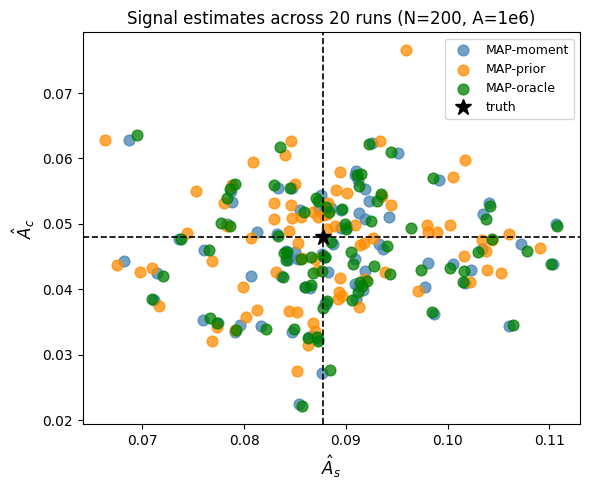

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))

estimators = [('MAP-moment', beta_moment, 'steelblue'),
              ('MAP-prior',  beta_prior,  'darkorange'),
              ('MAP-oracle', beta_oracle, 'green')]

for label, betas, color in estimators:
    ax.scatter(betas[:,0], betas[:,1], s=60, alpha=0.75, color=color, label=label)

ax.axvline(As_true, color='k', lw=1.2, ls='--')
ax.axhline(Ac_true, color='k', lw=1.2, ls='--')
ax.plot(As_true, Ac_true, 'k*', ms=12, label='truth', zorder=5)
ax.set_xlabel(r'$\hat{A}_s$', fontsize=12)
ax.set_ylabel(r'$\hat{A}_c$', fontsize=12)
ax.set_title('Signal estimates across 20 runs (N=200, A=1e6)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


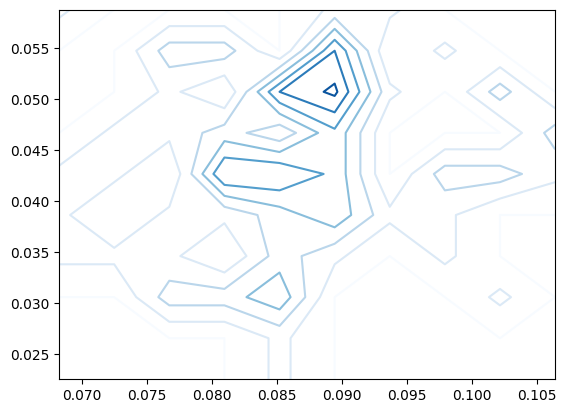

In [4]:
c,x,y=np.histogram2d(beta_moment[:,0], beta_moment[:,1])
plt.contour(x[:-1], y[:-1], c.T, cmap='Blues')

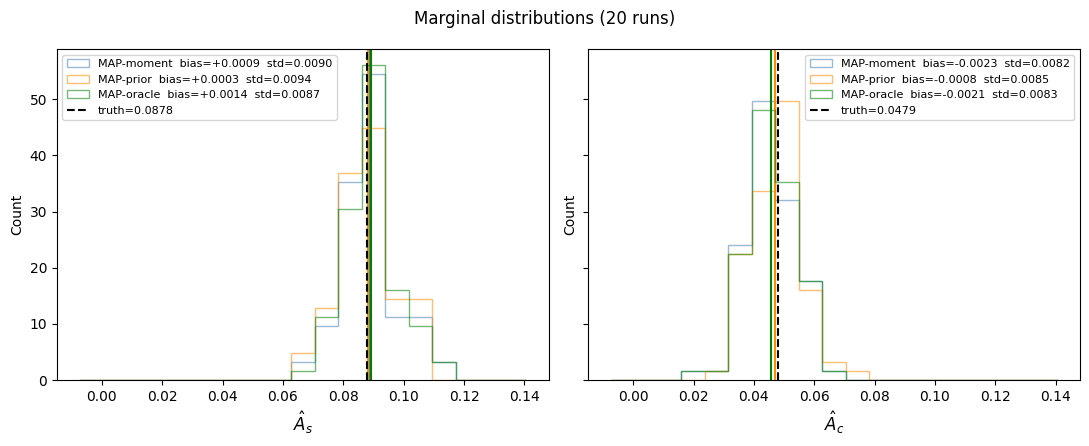

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

truths = [As_true, Ac_true]
param_labels = [r'$\hat{A}_s$', r'$\hat{A}_c$']
estimators = [('MAP-moment', beta_moment, 'steelblue'),
              ('MAP-prior',  beta_prior,  'darkorange'),
                ('MAP-oracle', beta_oracle, 'green')]

bins = np.linspace(
    min(beta_moment.min(), beta_prior.min()) - 0.03,
    max(beta_moment.max(), beta_prior.max()) + 0.03,
    20)

for col, (param_label, truth) in enumerate(zip(param_labels, truths)):
    ax = axes[col]
    for est_label, betas, color in estimators:
        vals = betas[:, col]
        bias = vals.mean() - truth
        ax.hist(vals, bins=bins, color=color, alpha=0.55,
                label=f'{est_label}  bias={bias:+.4f}  std={vals.std():.4f}', density=True, histtype='step')
        ax.axvline(vals.mean(), color=color, lw=1.5, ls='-')
    ax.axvline(truth, color='k', lw=1.5, ls='--', label=f'truth={truth:.4f}')
    ax.set_xlabel(param_label, fontsize=12)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Marginal distributions (20 runs)', fontsize=12)
plt.tight_layout()
plt.show()


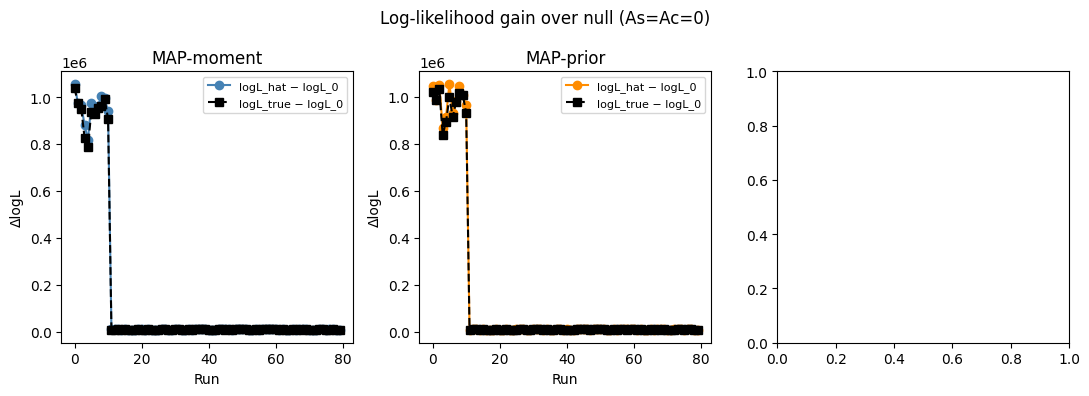

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))

for ax, runs, label, color in zip(
        axes,
        [moment_runs, prior_runs,],
        ['MAP-moment', 'MAP-prior', ],
        ['steelblue', 'darkorange', ]):
    lhat  = np.array([r['logL_hat']  for r in runs])
    ltrue = np.array([r['logL_true'] for r in runs])
    lzero = np.array([r['logL_zero'] for r in runs])
    idx = np.arange(len(runs))
    ax.plot(idx, lhat  - lzero, 'o-',  color=color, label='logL_hat − logL_0')
    ax.plot(idx, ltrue - lzero, 's--', color='k',   label='logL_true − logL_0')
    ax.set_xlabel('Run')
    ax.set_ylabel('ΔlogL')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('Log-likelihood gain over null (As=Ac=0)')
plt.tight_layout()
plt.show()


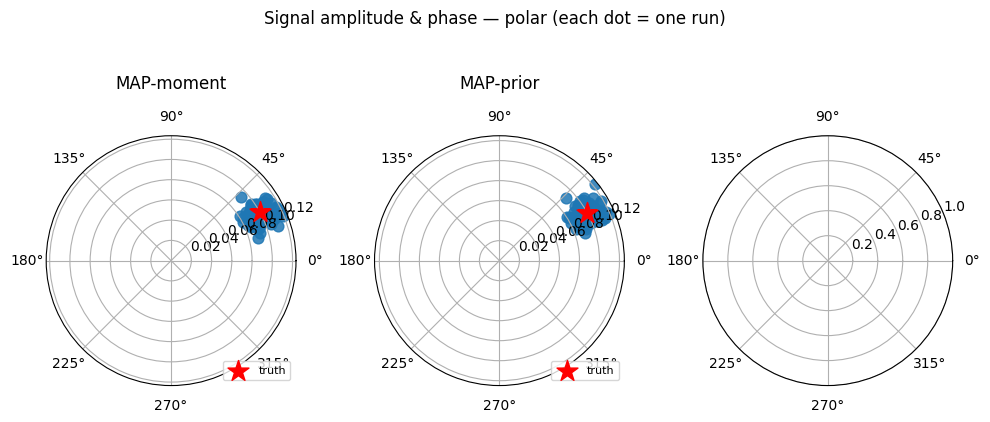

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4.5), subplot_kw={'projection': 'polar'})

A_true   = np.sqrt(As_true**2 + Ac_true**2)
phi_true = np.arctan2(Ac_true, As_true)

for ax, betas, label in zip(axes, [beta_moment, beta_prior, ], ['MAP-moment', 'MAP-prior', ]):
    A_hat   = np.sqrt(betas[:,0]**2 + betas[:,1]**2)
    phi_hat = np.arctan2(betas[:,1], betas[:,0])
    ax.scatter(phi_hat, A_hat, s=60, alpha=0.85)
    ax.scatter([phi_true], [A_true], marker='*', s=250, color='red', zorder=5, label='truth')
    ax.set_title(label, pad=15)
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('Signal amplitude & phase — polar (each dot = one run)', y=1.02)
plt.tight_layout()
plt.show()


800 shot-residuals from 80 runs

param              bias  std_resid  prior_σ  reduction
------------------------------------------------------
mu_x_0           +0.575      9.515     10.0   × 1.05  (μm)
mu_y_0           +0.254      9.714     10.0   × 1.03  (μm)
mu_v_x           -0.137      2.512     10.0   × 3.98  (μm/s)
mu_v_y           -0.065      2.569     10.0   × 3.89  (μm/s)
sigma_x_0        +0.258      9.957     10.0   × 1.00  (μm)
sigma_y_0        -0.425      9.655     10.0   × 1.04  (μm)
sigma_v_x        -0.431      8.899     10.0   × 1.12  (μm/s)
sigma_v_y        +0.354      8.788     10.0   × 1.14  (μm/s)


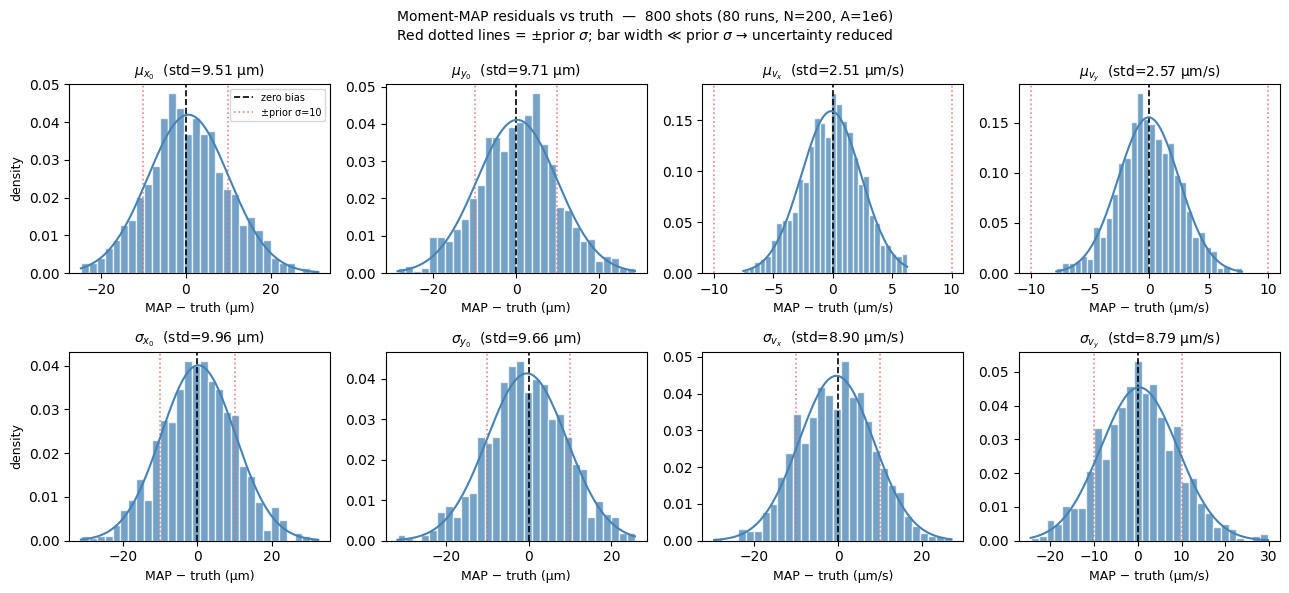

In [8]:

# ── Moment-MAP vs true η: residuals across all shots & runs ───────────────────
# eta_hat_z0 ordering (10-elem): [mu_x0, mu_vx0, mu_y0, mu_vy0,
#                                  V_x0, C_xv, V_vx0, V_y0, C_yv, V_vy0]
# theta_true_z0 ordering (8-elem): [mu_x0, mu_y0, mu_vx0, mu_vy0,
#                                    sigma_x, sigma_y, sigma_vx, sigma_vy]
SCALE = 1e6   # m → μm / m/s → μm/s

param_labels  = [r'$\mu_{x_0}$', r'$\mu_{y_0}$',
                 r'$\mu_{v_x}$', r'$\mu_{v_y}$',
                 r'$\sigma_{x_0}$', r'$\sigma_{y_0}$',
                 r'$\sigma_{v_x}$', r'$\sigma_{v_y}$']
param_units   = ['μm', 'μm', 'μm/s', 'μm/s', 'μm', 'μm', 'μm/s', 'μm/s']
prior_sigma   = [10., 10., 10., 10., 10., 10., 10., 10.]   # same units after scaling

def extract_hat(eta):
    """Map 10-elem eta_hat to 8-elem [mu_x0,mu_y0,mu_vx0,mu_vy0,sx,sy,svx,svy]."""
    mu_x0  = eta[0];  mu_y0  = eta[2]
    mu_vx0 = eta[1];  mu_vy0 = eta[3]
    sig_x0  = max(eta[4], 0.)**0.5
    sig_y0  = max(eta[7], 0.)**0.5
    sig_vx0 = max(eta[6], 0.)**0.5
    sig_vy0 = max(eta[9], 0.)**0.5
    return np.array([mu_x0, mu_y0, mu_vx0, mu_vy0, sig_x0, sig_y0, sig_vx0, sig_vy0])

def extract_true(theta):
    """theta_true is already [mu_x0,mu_y0,mu_vx0,mu_vy0,sx,sy,svx,svy]."""
    return theta

hats, trues = [], []
for run in moment_runs:
    for row in run['diag_rows']:
        hats.append(extract_hat(row['eta_hat_z0']) * SCALE)
        trues.append(extract_true(row['theta_true_z0']) * SCALE)

hats  = np.array(hats)    # (N_shots_total, 8)
trues = np.array(trues)
resid = hats - trues       # (N_shots_total, 8)
N_total = len(resid)
print(f'{N_total} shot-residuals from {len(moment_runs)} runs')

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"param":<14} {"bias":>8} {"std_resid":>10} {"prior_σ":>8} {"reduction":>10}')
print('-' * 54)
for i, (lbl, unit, ps) in enumerate(zip(param_labels, param_units, prior_sigma)):
    bias = resid[:, i].mean()
    std  = resid[:, i].std()
    lbl_plain = lbl.replace('$','').replace('{','').replace('}','').replace('\\','')
    print(f'{lbl_plain:<14} {bias:>+8.3f} {std:>10.3f} {ps:>8.1f}   ×{ps/std:5.2f}  ({unit})')

# ── Residual histograms ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
axes = axes.ravel()

for i, (ax, lbl, unit, ps) in enumerate(zip(axes, param_labels, param_units, prior_sigma)):
    r = resid[:, i]
    ax.hist(r, bins=30, color='steelblue', alpha=0.75, edgecolor='white', density=True)
    ax.axvline(0,   color='k',      lw=1.2, ls='--', label='zero bias')
    ax.axvline(-ps, color='#e66767', lw=1.2, ls=':', alpha=0.8, label=f'±prior σ={ps:.0f}')
    ax.axvline( ps, color='#e66767', lw=1.2, ls=':', alpha=0.8)
    # Gaussian with residual std
    x = np.linspace(r.min(), r.max(), 200)
    from scipy.stats import norm
    ax.plot(x, norm.pdf(x, r.mean(), r.std()), 'steelblue', lw=1.5)
    ax.set_title(f'{lbl}  (std={r.std():.2f} {unit})', fontsize=10)
    ax.set_xlabel(f'MAP − truth ({unit})', fontsize=9)
    ax.set_ylabel('density' if i % 4 == 0 else '', fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle(
    f'Moment-MAP residuals vs truth  —  {N_total} shots ({len(moment_runs)} runs, '
    f'N=200, A=1e6)\n'
    r'Red dotted lines = ±prior $\sigma$; bar width ≪ prior $\sigma$ → uncertainty reduced',
    fontsize=10)
plt.tight_layout()
plt.show()
